Copyright 2026 Google LLC.

SPDX-License-Identifier: Apache-2.0

In [ ]:
# @title TIPSv2 Segmentation, Depth, and Normals DPT Notebook

#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at

#  https://www.apache.org/licenses/LICENSE-2.0

#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.

In [ ]:
# @title Install dependencies and clone TIPS repo
import os
import sys

# Root directory for all files (Colab default is /content).
ROOT_DIR = os.getcwd()
TIPS_DIR = os.path.join(ROOT_DIR, 'tips')

# Install required packages.
!pip install -q torch torchvision torchaudio
!pip install -q tensorflow_text mediapy jax jaxlib scikit-learn

# Clone the TIPS repository.
if not os.path.exists(TIPS_DIR):
  !git clone --branch add-decoders-module https://github.com/google-deepmind/tips.git {TIPS_DIR}

# Add the root directory to PYTHONPATH so that `tips.*` imports work.
if ROOT_DIR not in sys.path:
  sys.path.insert(0, ROOT_DIR)

print(f'ROOT_DIR: {ROOT_DIR}')
print(f'TIPS_DIR: {TIPS_DIR}')
print('Installation complete!')

ROOT_DIR: /content
TIPS_DIR: /content/tips
Installation complete!


In [ ]:
# @title Download the checkpoints and NYU Dataset
import urllib.request
import zipfile

variant = 'L'  # @param ["B", "L", "So", "g"]

CHECKPOINT_BASE_URL = 'https://storage.googleapis.com/tips_data/v2_0/checkpoints/pytorch'
TOKENIZER_URL = 'https://storage.googleapis.com/tips_data/v1_0/checkpoints/tokenizer.model'
NYU_URL = 'http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/bedrooms_part6.zip'
NYU_TMP_PATH = os.path.join(ROOT_DIR, 'bedrooms_part6.zip')

# Directories for checkpoints (under ROOT_DIR).
CKPT_DIR = os.path.join(ROOT_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# Mapping from variant to checkpoint basenames (matches GCS naming).
V2_CKPT_BASENAME_MAP = {
    'B': 'tips_v2_oss_b14',
    'L': 'tips_v2_oss_l14',
    'So': 'tips_v2_oss_so14',
    'g': 'tips_v2_oss_g14',
}
# DPT checkpoint naming uses a different convention (no "oss").
V2_DPT_BASENAME_MAP = {
    'B': 'tips_v2_b14',
    'L': 'tips_v2_l14',
    'So': 'tips_v2_so400m14',
    'g': 'tips_v2_g14',
}
ckpt_basename = V2_CKPT_BASENAME_MAP[variant]
dpt_basename = V2_DPT_BASENAME_MAP[variant]

# Download the TIPS vision encoder checkpoint.
vision_ckpt_name = f'{ckpt_basename}_vision.npz'
vision_ckpt_url = f'{CHECKPOINT_BASE_URL}/{vision_ckpt_name}'
image_encoder_checkpoint = os.path.join(CKPT_DIR, vision_ckpt_name)
if not os.path.exists(image_encoder_checkpoint):
  print(f'Downloading vision encoder: {vision_ckpt_url}...')
  urllib.request.urlretrieve(vision_ckpt_url, image_encoder_checkpoint)

# Download the TIPS text encoder checkpoint.
text_ckpt_name = f'{ckpt_basename}_text.npz'
text_ckpt_url = f'{CHECKPOINT_BASE_URL}/{text_ckpt_name}'
text_encoder_checkpoint = os.path.join(CKPT_DIR, text_ckpt_name)
if not os.path.exists(text_encoder_checkpoint):
  print(f'Downloading text encoder: {text_ckpt_url}...')
  urllib.request.urlretrieve(text_ckpt_url, text_encoder_checkpoint)

# Download the tokenizer model.
tokenizer_path = os.path.join(CKPT_DIR, 'tokenizer.model')
if not os.path.exists(tokenizer_path):
  print(f'Downloading tokenizer: {TOKENIZER_URL}...')
  urllib.request.urlretrieve(TOKENIZER_URL, tokenizer_path)

# Download DPT checkpoints (Segmentation, Depth, Normals).
dpt_tasks = ['segmentation', 'depth', 'normals']
dpt_checkpoint_paths = {}

for task in dpt_tasks:
  dpt_zip_name = f'{dpt_basename}_{task}_dpt_pytorch.zip'
  dpt_zip_url = f'{CHECKPOINT_BASE_URL}/{dpt_zip_name}'
  dpt_zip_path = os.path.join(CKPT_DIR, dpt_zip_name)

  if not os.path.exists(dpt_zip_path):
    print(f'Downloading DPT {task} checkpoint: {dpt_zip_url}...')
    try:
      urllib.request.urlretrieve(dpt_zip_url, dpt_zip_path)
      # Extract the .npz file(s) from the zip.
      with zipfile.ZipFile(dpt_zip_path, 'r') as zf:
        zf.extractall(CKPT_DIR)
        print(f'  Extracted {task} checkpoint to {CKPT_DIR}')
    except Exception as e:
      print(f'  Failed to download {dpt_zip_name}: {e}')
  else:
    print(f'  DPT {task} checkpoint already exists.')

  # Assume the extracted file has the same name as inside the zip, or we just use the zip path if load_decoder_weights supports it.
  # For now, we pass the zip path as in the original notebook.
  dpt_checkpoint_paths[task] = dpt_zip_path

# Download and extract NYU dataset for sample images.
NYU_IMG_DIR = os.path.join(ROOT_DIR, 'nyu_images')
if not os.path.isdir(NYU_IMG_DIR):
  print('\nDownloading NYU dataset (bedrooms_part6.zip)...')
  try:
    urllib.request.urlretrieve(NYU_URL, NYU_TMP_PATH)
    print('Extracting NYU images...')
    os.makedirs(NYU_IMG_DIR, exist_ok=True)
    with zipfile.ZipFile(NYU_TMP_PATH, 'r') as z:
      z.extractall(NYU_IMG_DIR)
    os.remove(NYU_TMP_PATH)
    print(f'  Extracted to {NYU_IMG_DIR}')
  except Exception as e:
    print(f'  Failed to download or extract NYU dataset: {e}')
else:
  print('  NYU images already extracted.')

IMG_DIR = NYU_IMG_DIR
print('\nAll downloads complete!')

  Extracted segmentation checkpoint to /content/checkpoints
  Extracted depth checkpoint to /content/checkpoints
  Extracted normals checkpoint to /content/checkpoints
  NYU images already extracted.

All downloads complete!


In [ ]:
# @title Configure the TIPS model.

# Set the input image shape.
image_size = 448  # @param {type: "number"}

# variant, image_encoder_checkpoint, text_encoder_checkpoint, tokenizer_path, dpt_zip_path
# are all set in the download cell (Cell [3]) above.

# Use the zip file path directly as the checkpoint, since .npz IS a zip file.
dpt_checkpoint = dpt_zip_path

print(f'Image encoder checkpoint: {image_encoder_checkpoint}')
print(f'Text encoder checkpoint: {text_encoder_checkpoint}')
print(f'Tokenizer path: {tokenizer_path}')
print(f'DPT checkpoint (PyTorch .zip as .npz): {dpt_checkpoint}')

Image encoder checkpoint: /content/checkpoints/tips_v2_oss_l14_vision.npz
Text encoder checkpoint: /content/checkpoints/tips_v2_oss_l14_text.npz
Tokenizer path: /content/checkpoints/tokenizer.model
DPT checkpoint (PyTorch .zip as .npz): /content/checkpoints/tips_v2_l14_normals_dpt_pytorch.zip


In [ ]:
# @title Load TIPS Model and All Decoders
import numpy as np
import torch
from tips.pytorch import image_encoder
from tips.pytorch.decoders import SegmentationDecoder, NormalsDecoder, load_decoder_weights

PATCH_SIZE = 14
weights_image = dict(np.load(image_encoder_checkpoint, allow_pickle=False))
for key in weights_image:
    weights_image[key] = torch.tensor(weights_image[key])
ffn_layer = 'swiglu' if variant == 'g' else 'mlp'

MODEL_CONSTRUCTOR_MAP = {'B': 'vit_base', 'L': 'vit_large', 'So': 'vit_so400m', 'g': 'vit_giant2'}
EMBED_DIM_MAP = {'B': 768, 'L': 1024, 'So': 1152, 'g': 1536}
INTERMEDIATE_LAYERS_MAP = {
    'B': [2, 5, 8, 11],
    'L': [5, 11, 17, 23],
    'So': [6, 13, 20, 26],
    'g': [9, 19, 29, 39],
}

vit_constructor = getattr(image_encoder, MODEL_CONSTRUCTOR_MAP[variant])
embed_dim = EMBED_DIM_MAP[variant]
intermediate_layers = INTERMEDIATE_LAYERS_MAP[variant]
post_process_channels = (embed_dim // 8, embed_dim // 4, embed_dim // 2, embed_dim)

# Load Vision Encoder
with torch.no_grad():
  model_image = vit_constructor(
      img_size=image_size, patch_size=PATCH_SIZE, ffn_layer=ffn_layer,
      block_chunks=0, init_values=1.0, interpolate_antialias=True, interpolate_offset=0.0,
  )
  model_image.load_state_dict(weights_image)
  model_image.eval()

# Load Segmentation Decoder
with torch.no_grad():
  seg_model = SegmentationDecoder(
      num_classes=150,
      input_embed_dim=embed_dim,
      post_process_channels=post_process_channels,
  )
  load_decoder_weights(seg_model, dpt_checkpoint_paths['segmentation'])
  seg_model.eval()

# WORKAROUND: Load Depth Decoder using SegmentationDecoder with 256 classes
# to match the classification head in the checkpoint.
with torch.no_grad():
  depth_model = SegmentationDecoder(
      num_classes=256,
      input_embed_dim=embed_dim,
      post_process_channels=post_process_channels,
  )
  load_decoder_weights(depth_model, dpt_checkpoint_paths['depth'])
  depth_model.eval()

# Load Normals Decoder
with torch.no_grad():
  normals_model = NormalsDecoder(
      input_embed_dim=embed_dim,
      post_process_channels=post_process_channels,
  )
  load_decoder_weights(normals_model, dpt_checkpoint_paths['normals'])
  normals_model.eval()

print(f"TIPS model and all DPT heads loaded successfully!")

/content/tips/pytorch/image_encoder.py:175: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")


Loaded decoder weights from /content/checkpoints/tips_v2_l14_segmentation_dpt_pytorch.zip (52 tensors)
Loaded decoder weights from /content/checkpoints/tips_v2_l14_depth_dpt_pytorch.zip (52 tensors)
Loaded decoder weights from /content/checkpoints/tips_v2_l14_normals_dpt_pytorch.zip (52 tensors)
TIPS model and all DPT heads loaded successfully!


In [ ]:
# @title Define ADE20K Classes and Palette
import colorsys

ADE20K_CLASSES = (
    'wall', 'building', 'sky', 'floor', 'tree', 'ceiling', 'road', 'bed', 'windowpane', 'grass',
    'cabinet', 'sidewalk', 'person', 'earth', 'door', 'table', 'mountain', 'plant', 'curtain', 'chair',
    'car', 'water', 'painting', 'sofa', 'shelf', 'house', 'sea', 'mirror', 'rug', 'field',
    'armchair', 'seat', 'fence', 'desk', 'rock', 'wardrobe', 'lamp', 'bathtub', 'railing', 'cushion',
    'base', 'box', 'column', 'signboard', 'chest of drawers', 'counter', 'sand', 'sink', 'skyscraper', 'fireplace',
    'refrigerator', 'grandstand', 'path', 'stairs', 'runway', 'case', 'pool table', 'pillow', 'screen door', 'stairway',
    'river', 'bridge', 'bookcase', 'blind', 'coffee table', 'toilet', 'flower', 'book', 'hill', 'bench',
    'countertop', 'stove', 'palm', 'kitchen island', 'computer', 'swivel chair', 'boat', 'bar', 'arcade machine', 'hovel',
    'bus', 'towel', 'light', 'truck', 'tower', 'chandelier', 'awning', 'streetlight', 'booth', 'television',
    'airplane', 'dirt track', 'apparel', 'pole', 'land', 'bannister', 'escalator', 'ottoman', 'bottle', 'buffet',
    'poster', 'stage', 'van', 'ship', 'fountain', 'conveyer belt', 'canopy', 'washer', 'plaything', 'swimming pool',
    'stool', 'barrel', 'basket', 'waterfall', 'tent', 'bag', 'minibike', 'cradle', 'oven', 'ball',
    'food', 'step', 'tank', 'trade name', 'microwave', 'pot', 'animal', 'bicycle', 'lake', 'dishwasher',
    'screen', 'blanket', 'sculpture', 'hood', 'sconce', 'vase', 'traffic light', 'tray', 'ashcan', 'fan',
    'pier', 'crt screen', 'plate', 'monitor', 'bulletin board', 'shower', 'radiator', 'glass', 'clock', 'flag'
)

NUM_ADE20K_CLASSES = 150
ADE20K_PALETTE = np.zeros((NUM_ADE20K_CLASSES + 1, 3), dtype=np.uint8)
for i in range(1, NUM_ADE20K_CLASSES + 1):
    hue = (i * 0.618033988749895) % 1.0
    rgb = colorsys.hls_to_rgb(hue, 0.5, 0.5)
    ADE20K_PALETTE[i] = [int(x * 255) for x in rgb]

print(f'Defined {len(ADE20K_CLASSES)} classes and palette.')

Defined 150 classes and palette.


Using image: /content/nyu_images/bedroom_0101/r-1315270058.602643-2503820951.ppm


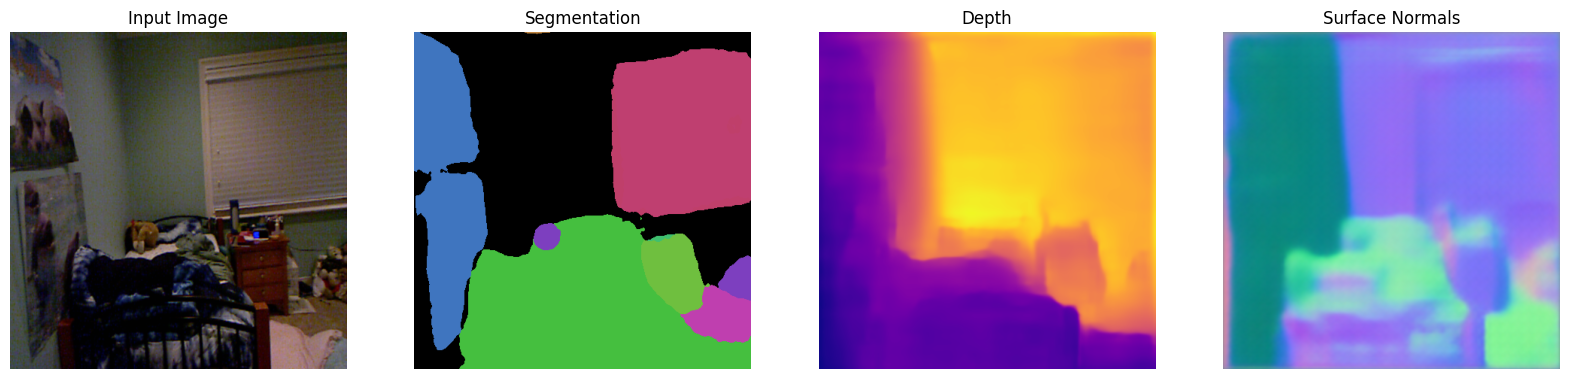

In [ ]:
# @title Run Inference on a Sample NYU Image
import PIL.Image
import matplotlib.pyplot as plt
import torchvision.transforms as TVT

# Find a sample image in the extracted NYU dataset.
nyu_images = []
# NYU raw dataset uses .ppm for RGB images. We also check for standard formats.
valid_extensions = ('.ppm', '.jpg', '.jpeg', '.png')

for root, dirs, files in os.walk(IMG_DIR):
    for file in files:
        if file.lower().endswith(valid_extensions):
            nyu_images.append(os.path.join(root, file))

if not nyu_images:
  # If nothing is found, let's see what files ARE there to help debug.
  all_files = []
  for r, d, f in os.walk(IMG_DIR):
      all_files.extend(f)
  print(f"Warning: No images with extensions {valid_extensions} found in {IMG_DIR}.")
  print(f"Sample of files actually found (total {len(all_files)}): {all_files[:10]}")
  raise FileNotFoundError(f"No valid images found in {IMG_DIR}")

# Pick the first available image
image_path = sorted(nyu_images)[0]
print(f'Using image: {image_path}')
img = PIL.Image.open(image_path)

transform = TVT.Compose([TVT.Resize((image_size, image_size)), TVT.ToTensor()])
tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    # Get intermediate features from ViT
    features = model_image.get_intermediate_layers(
        tensor, n=intermediate_layers, reshape=True, return_class_token=True, norm=True
    )
    # Swap order for decoder: (feat, cls) -> (cls, feat)
    features = [(cls, feat) for feat, cls in features]

    # 1. Run Segmentation
    seg_logits = seg_model(features, image_size=(image_size, image_size))
    seg_map = seg_logits.argmax(dim=1).squeeze(0).cpu().numpy()

    # 2. Run Depth (Post-processing for classification head)
    depth_logits = depth_model(features, image_size=(image_size, image_size)) # (B, 256, H, W)

    min_depth = 0.001 # Typical min depth for NYU
    max_depth = 10.0  # Typical max depth for NYU

    # Apply ReLU and shift (matching Scenic's implementation)
    depth_logits = torch.relu(depth_logits) + min_depth
    # Normalize to probabilities along the channel dimension
    depth_probs = depth_logits / torch.sum(depth_logits, dim=1, keepdim=True)

    # Create bin centers
    bin_centers = torch.linspace(min_depth, max_depth, 256, device=depth_logits.device)
    # Compute expectation: sum(prob * bin_center)
    depth_map = torch.einsum('bchw,c->bhw', depth_probs, bin_centers)
    depth_map = depth_map.squeeze().cpu().numpy()

    # 3. Run Normals
    normals_map = normals_model(features, image_size=(image_size, image_size))
    normals_map = normals_map.squeeze(0).cpu().numpy() # (3, H, W)
    # Transpose to (H, W, 3) for plotting and normalize to [0, 1]
    normals_map = (np.transpose(normals_map, (1, 2, 0)) + 1.0) / 2.0

# Visualize results
# Assuming ADE20K_PALETTE is defined in Cell 7
colored_seg = ADE20K_PALETTE[seg_map]

plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1); plt.imshow(img.resize((image_size, image_size))); plt.title("Input Image"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(colored_seg); plt.title("Segmentation"); plt.axis("off")
plt.subplot(1, 4, 3); plt.imshow(depth_map, cmap='plasma'); plt.title("Depth"); plt.axis("off")
plt.subplot(1, 4, 4); plt.imshow(normals_map); plt.title("Surface Normals"); plt.axis("off")
plt.show()